# 🩺 第十六天 · pandas 实战日：真实公开数据集全流程

**今天目标（约 1.5-2 小时）**：独立完成「读 → 看 → 洗 → 筛/分组 → 出结论」全流程，产出一份迷你分析报告。

**数据**：`pima_diabetes.csv`（Pima 印第安人糖尿病数据集，768 行，已放本目录）

**字段含义**（顺序即列顺序，文件没有表头）：

| 列名 | 含义 |
|---|---|
| Pregnancies | 怀孕次数 |
| Glucose | 血糖（mg/dL） |
| BloodPressure | 血压 |
| SkinThickness | 皮褶厚度 |
| Insulin | 胰岛素 |
| BMI | 体重指数 |
| DiabetesPedigreeFunction | 糖尿病遗传函数 |
| Age | 年龄 |
| Outcome | 结局（0=未患糖尿病，1=患糖尿病） |

> ⚠️ 先 **Kernel → Restart Kernel**。
>
> 今天没有标准答案，按步骤自己写，写一步验证一步。

## 第 1 步 · 读：文件没有表头，读入时自己命名

这个 CSV **没有表头行**（第一行就是数据），所以 `read_csv` 要加两个参数：

```python
pd.read_csv("pima_diabetes.csv", header=None, names=[...])
```

### 练习 1：读入数据

用上面写法读入，`names` 用这个列表（9 个英文列名）：

```python
["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
 "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
```

然后 `head()` 看前 5 行。

In [2]:
# 在这里写你的代码
import pandas as pd
df=pd.read_csv("pima_diabetes.csv",header=None,names=["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
 "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"])
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 第 2 步 · 看：shape / info / describe

### 练习 2：三连查

① `shape` 几行几列；② `info()` 看类型；③ `describe()` 看数值统计。

**重点观察 describe 里的 min 行**——有没有让你觉得不对劲的最小值？

In [8]:
# 在这里写你的代码
print(df.shape)
print(df.info())
print(df.describe())

(768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std      

## 第 3 步 · 洗：医学常识发现「假 0」

用医学常识想：**血糖、血压、BMI、皮褶厚度、胰岛素不可能是 0**——这些 0 其实是「缺失值」，只是当年录入时用 0 代替了。

处理套路：把 5 列的 0 **替换成 NaN**，再统计缺失、再填充。

替换写法（`replace` 把 0 换成 NaN，需要先 `import numpy as np`）：

```python
df["Glucose"] = df["Glucose"].replace(0, np.nan)
```

### 练习 3：把 5 列的 0 换成 NaN，再统计每列缺失数

5 列：Glucose、BloodPressure、SkinThickness、Insulin、BMI。

In [11]:
# 在这里写你的代码
import numpy as np
df["Glucose"]=df["Glucose"].replace(0,np.nan)
df["BloodPressure"]=df["BloodPressure"].replace(0,np.nan)
df["SkinThickness"]=df["SkinThickness"].replace(0,np.nan)
df["Insulin"]=df["Insulin"].replace(0,np.nan)
df["BMI"]=df["BMI"].replace(0,np.nan)
print(df.isnull().sum()) 

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


## 第 4 步 · 填：用中位数填充缺失

### 练习 4：把 5 列的 NaN 用各自的中位数填上，填完验证每列缺失数都是 0

提示：D15 的练习 5 你做过一模一样的操作（`.fillna(df["列"].median())`），今天要填 5 列。

In [14]:
# 在这里写你的代码
df["Glucose"]=df["Glucose"].fillna(df["Glucose"].median())
df["BloodPressure"]=df["BloodPressure"].fillna(df["BloodPressure"].median())
df["SkinThickness"]=df["SkinThickness"].fillna(df["SkinThickness"].median())
df["Insulin"]=df["Insulin"].fillna(df["Insulin"].median())
df["BMI"]=df["BMI"].fillna(df["BMI"].median())
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


## 第 5 步 · 分组对比（今天核心）

医学问题：**患病组（Outcome=1）和未患病组（Outcome=0）的指标有什么差异？**

新知识：一次取**多列**要用**双中括号**：`df[["Glucose", "BMI", "Age"]]`

### 练习 5：按 Outcome 分组，算 Glucose、BMI、Age 三列的均值

写法骨架：`df.groupby("Outcome")[[...三列...]].mean()`

In [3]:
# 在这里写你的代码
df.groupby("Outcome")[["Glucose", "BMI", "Age"]].mean()


,Glucose,BMI,Age
Outcome,,,
0,109.980000,30.304200,31.190000
1,141.257463,35.142537,37.067164


## 第 6 步 · 筛选

### 练习 6：筛出「血糖 > 140」的人，数一数有多少人，其中患病（Outcome=1）的有几个

提示：先 `df[df["Glucose"] > 140]` 存变量，再对这个子集做 `value_counts`。

In [8]:
# 在这里写你的代码
high = df[df["Glucose"] > 140]
print("血糖>140 的人数:", len(high))
print(high["Outcome"].value_counts())

血糖>140 的人数: 192
Outcome
1    132
0     60
Name: count, dtype: int64


## 第 7 步 · 出结论（加分题）

### 练习 7：画一张图 + 写 3 个发现

画图（柱状图对比两组平均血糖）：

```python
df.groupby("Outcome")["Glucose"].mean().plot(kind="bar")
```

然后在下方的 markdown 单元格里，写下你从数据中发现的 **3 个结论**（例：「患病组平均血糖明显高于未患病组」）。

<Axes: xlabel='Outcome'>

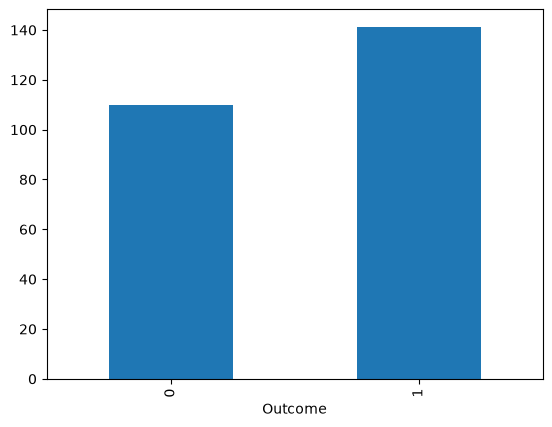

In [10]:
# 在这里写你的代码（画图）
df.groupby("Outcome")["Glucose"].mean().plot(kind="bar")

### 我的 3 个发现

1. 患病组平均血糖明显高于未患病组
2. 患者组血糖大于140的人数远大于对照组
3. 患者组的BMI平均指高于对照组

## ✅ D16 完成标准（打钩）

- [ ] 练习 1-6 全部跑通
- [ ] 练习 3 能识别并处理「假 0」
- [ ] 练习 5 能按 Outcome 分组对比三列均值
- [ ] 练习 7 画了图、写了 3 个发现
- [ ] 保存（**Cmd + S**）

完成后喊我验收。D17 学**大模型工具使用**——用 DeepSeek 辅助医学学习、收集幻觉实例。